作業我使用 TensorFlow 建立全連結神經網路（DNN）來進行 MNIST 手寫數字辨識。
- 資料集：MNIST
- 模型：4層 Dense

## 讀入套件

In [ ]:
%matplotlib inline

# 標準數據分析、畫圖套件
import numpy as np
import matplotlib.pyplot as plt

# 神經網路方面
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# 互動設計用
from ipywidgets import interact_manual


# 載入 MNIST 手寫數字資料集

In [ ]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
print(f'訓練資料總筆數為 {len(x_train)} 筆資料')
print(f'測試資料總筆數為 {len(x_test)} 筆資料')

訓練資料總筆數為 60000 筆資料
測試資料總筆數為 10000 筆資料


# 資料前處理

In [ ]:
# 將 28x28 圖片攤平成 784 維向量，並做正規化
x_train = x_train.reshape(60000, 784).astype("float32") / 255
x_test = x_test.reshape(10000, 784).astype("float32") / 255

# 將答案轉成 one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

print("處理後 x_train shape:", x_train.shape)
print("處理後 x_test shape:", x_test.shape)
print("處理後 y_train shape:", y_train.shape)
print("處理後 y_test shape:", y_test.shape)

處理後 x_train shape: (60000, 784)
處理後 x_test shape: (10000, 784)
處理後 y_train shape: (60000, 10)
處理後 y_test shape: (10000, 10)


# 建立你的模型



## 要測多組的寫法
先寫一個「建立模型」的函式



In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

def build_model():
    model = Sequential([
        Dense(256, input_dim=784, activation='relu'),
        Dropout(0.2),
        Dense(128, activation='relu'),
        Dense(64, activation='relu'),
        Dense(32, activation='relu'),
        Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

### 建構神經網路講解

標準一層一層傳遞的神經網路叫 `Sequential`, 於是我們打開一個空的神經網路進行建構

我們每次用 `add` 去加一層, 從第一個隱藏層開始。而第一個隱藏層因為 TensorFlow 當然猜不到輸入有 784 個 features, 所以我們要告訴它。

第二層開始就不用再說明輸入神經元個數 (因為就是前一層神經元數)。

## 編譯模型

和之前比較不一樣的是我們還要做 `compile` 才正式把我們的神經網路建好。我們還需要做幾件事:

* 決定使用的 loss function, 一般是 `mse`
* 決定 optimizer, 我們用標準的 SGD
* 設 learning rate

為了一邊訓練一邊看到結果, 我們加設

    metrics=['accuracy']
    


本次使用:

In [ ]:

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

## 訓練實驗模型A(第一次參數調整)



* (`batch_size`):一次要訓練幾筆資料,此次帶入150
* (`epochs`): 這 6 萬筆資料一共要訓練幾次  本次訓練 15 次試試



In [ ]:
model_1 = build_model()

history_1 = model_1.fit(
    x_train, y_train,
    batch_size=150,
    epochs=15,
    validation_split=0.1,
    verbose=1
)



Epoch 1/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 6s 5ms/step - accuracy: 0.8888 - loss: 0.3707 - val_accuracy: 0.9668 - val_loss: 0.1124
Epoch 2/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9577 - loss: 0.1387 - val_accuracy: 0.9772 - val_loss: 0.0866
Epoch 3/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9684 - loss: 0.1006 - val_accuracy: 0.9783 - val_loss: 0.0721
Epoch 4/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9747 - loss: 0.0800 - val_accuracy: 0.9765 - val_loss: 0.0748
Epoch 5/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9800 - loss: 0.0637 - val_accuracy: 0.9783 - val_loss: 0.0732
Epoch 6/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9822 - loss: 0.0551 - val_accuracy: 0.9807 - val_loss: 0.0626
Epoch 7/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9840 - loss: 0.0502 - val_accuracy: 0.9812 - val_loss: 0.0669
Epoch 8/15
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9863 - loss: 0.0425 - val_accuracy: 0.

# 測試結果1 (model_1)

In [ ]:
loss_1, acc_1 = model_1.evaluate(x_test, y_test, verbose=0)
print(f"Experiment 1 accuracy: {acc_1*100:.2f}%")

Experiment 1 accuracy: 98.07%


In [ ]:
loss, acc = model.evaluate(x_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9809 - loss: 0.0838


In [ ]:
# 在測試資料上驗證模型
loss, acc = model.evaluate(x_test, y_test, verbose=0)
print(f"測試資料正確率: {acc * 100:.2f}%")

測試資料正確率: 98.09%


## 訓練實驗模型B(第二次參數調整)



* (`batch_size`):一次要訓練幾筆資料,此次帶入150
* (`epochs`): 這 6 萬筆資料一共要訓練幾次  本次訓練 10 次試試

In [ ]:
model_2 = build_model()

history_2 = model_2.fit(
    x_train, y_train,
    batch_size=150,
    epochs=10,
    validation_split=0.1,
    verbose=1
)


Epoch 1/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8741 - loss: 0.4047 - val_accuracy: 0.9655 - val_loss: 0.1174
Epoch 2/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9574 - loss: 0.1401 - val_accuracy: 0.9747 - val_loss: 0.0812
Epoch 3/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9688 - loss: 0.0997 - val_accuracy: 0.9773 - val_loss: 0.0706
Epoch 4/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9758 - loss: 0.0778 - val_accuracy: 0.9787 - val_loss: 0.0718
Epoch 5/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9795 - loss: 0.0651 - val_accuracy: 0.9808 - val_loss: 0.0688
Epoch 6/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9813 - loss: 0.0583 - val_accuracy: 0.9800 - val_loss: 0.0695
Epoch 7/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9847 - loss: 0.0466 - val_accuracy: 0.9798 - val_loss: 0.0706
Epoch 8/10
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9845 - loss: 0.0462 - val_accuracy: 0.

# 測試結果2 (model_2)

In [ ]:
loss_2, acc_2 = model_2.evaluate(x_test, y_test)


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9780 - loss: 0.0787


In [ ]:
print(f"Experiment 2 accuracy: {acc_2*100:.2f}%")

Experiment 2 accuracy: 97.80%


# 測試結果3 (model_3)

In [ ]:
model_3 = build_model()

history_3 = model_3.fit(
    x_train, y_train,
    batch_size=150,
    epochs=16,
    validation_split=0.1,
    verbose=1
)

loss_3, acc_3 = model_3.evaluate(x_test, y_test, verbose=0)
print(f"Experiment 3 accuracy: {acc_3*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/16
360/360 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8816 - loss: 0.3856 - val_accuracy: 0.9657 - val_loss: 0.1211
Epoch 2/16
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9581 - loss: 0.1386 - val_accuracy: 0.9745 - val_loss: 0.0894
Epoch 3/16
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9682 - loss: 0.1021 - val_accuracy: 0.9742 - val_loss: 0.0821
Epoch 4/16
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9748 - loss: 0.0813 - val_accuracy: 0.9795 - val_loss: 0.0727
Epoch 5/16
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9801 - loss: 0.0634 - val_accuracy: 0.9757 - val_loss: 0.0781
Epoch 6/16
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9822 - loss: 0.0565 - val_accuracy: 0.9778 - val_loss: 0.0720
Epoch 7/16
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9833 - loss: 0.0521 - val_accuracy: 0.9818 - val_loss: 0.0643
Epoch 8/16
360/360 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9868 - loss: 0.0420 - val_accuracy: 0.

# 測試結果4 (model_4)

In [ ]:
model_4 = build_model()

history_4 = model_4.fit(
    x_train, y_train,
    batch_size=150,
    epochs=17,
    validation_split=0.1,
    verbose=1
)

loss_4, acc_4 = model_4.evaluate(x_test, y_test, verbose=0)
print(f"Experiment 4 accuracy: {acc_4*100:.2f}%")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/17
360/360 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8867 - loss: 0.3704 - val_accuracy: 0.9652 - val_loss: 0.1186
Epoch 2/17
360/360 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9588 - loss: 0.1366 - val_accuracy: 0.9733 - val_loss: 0.0926
Epoch 3/17
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9700 - loss: 0.0981 - val_accuracy: 0.9773 - val_loss: 0.0794
Epoch 4/17
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9752 - loss: 0.0780 - val_accuracy: 0.9788 - val_loss: 0.0763
Epoch 5/17
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9805 - loss: 0.0618 - val_accuracy: 0.9822 - val_loss: 0.0695
Epoch 6/17
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9828 - loss: 0.0540 - val_accuracy: 0.9778 - val_loss: 0.0789
Epoch 7/17
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9855 - loss: 0.0465 - val_accuracy: 0.9815 - val_loss: 0.0688
Epoch 8/17
360/360 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9864 - loss: 0.0423 - val_accuracy: 0.

# 測試準確率心路歷程

In [ ]:
原本：

先隨便設 batch_size=150
epochs=15

In [ ]:
其實就還不錯了 ,但在想會不會大概 epoch 6~10 就差不多穩了
決定改成 epochs= 10 看看 ,結果準確率變低
那我又改 epochs= 16 看看 有增加準確率
改 epochs= 17 看看 微降準確率
那最後我就使用epochs= 16

# 顯示預測結果 (用測試完準確率最好得 model_3)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step


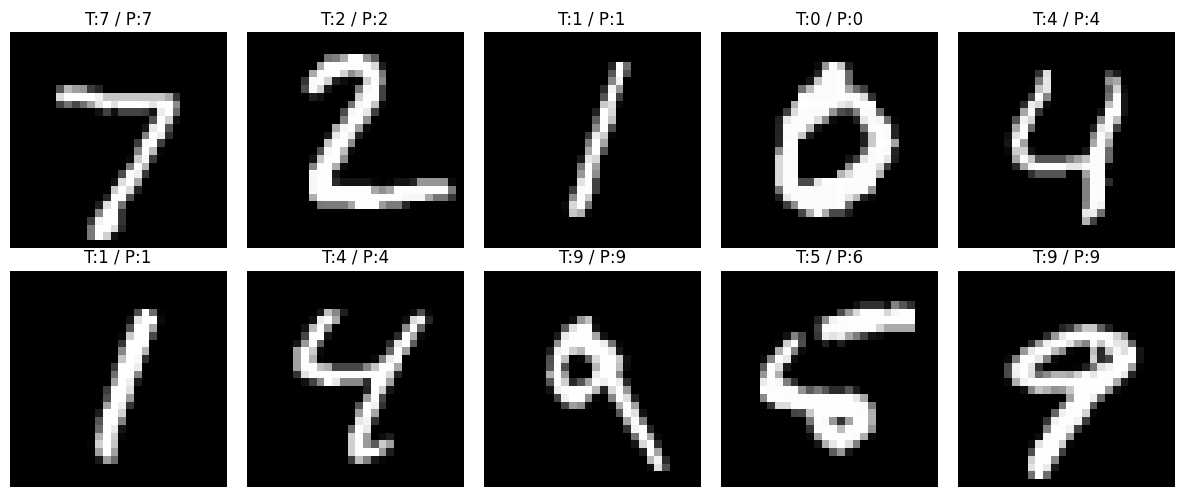

In [ ]:
predictions = np.argmax(model_3.predict(x_test[:10]), axis=-1)
true_labels = np.argmax(y_test[:10], axis=-1)

plt.figure(figsize=(12,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title(f"T:{true_labels[i]} / P:{predictions[i]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

新版 TensorFlow 也可以直接存成 .keras

In [ ]:
# 先不要掛 Google Drive，直接存到目前執行環境
model_3.save("my_mnist_dnn_model.keras")
print("模型已儲存到目前工作目錄")


模型已儲存到目前工作目錄


之後讀回來


In [ ]:
from tensorflow.keras.models import load_model

loaded_model = load_model("my_mnist_dnn_model.keras")
print("模型已成功讀回")

模型已成功讀回


#Gradio 展示

官方現在比較推薦 ImageEditor()。
可「直接手寫黑筆畫在白底上」

In [ ]:
import gradio as gr
import numpy as np
import tensorflow as tf

labels = list("0123456789")

def recognize_digit(editor_value):
    # ImageEditor 傳進來的是 dict，真正合成後的圖通常在 composite
    img = editor_value["composite"]
    img = np.array(img)

    # 若是彩色圖，轉灰階
    if len(img.shape) == 3:
        img = np.mean(img, axis=2)

    # resize 成 28x28
    img = tf.image.resize(img[..., np.newaxis], (28, 28)).numpy().squeeze()

    # 正規化
    img = img / 255.0

    # 攤平成 784 維
    img = img.reshape(1, 784)

    prediction = model_3.predict(img, verbose=0).flatten()
    return {labels[i]: float(prediction[i]) for i in range(10)}

demo = gr.Interface(
    fn=recognize_digit,
    inputs=gr.ImageEditor(
        sources=(),
        brush=gr.Brush(colors=["#000000"], color_mode="fixed")
    ),
    outputs=gr.Label(num_top_classes=3),
    title="MNIST 手寫數字辨識",
    description="請直接在畫板上寫一個數字。"
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://908b7a1279f620b5ad.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


# 懷疑上一版Demo 輸入格式和模型不一致 先確認是不是模型本身其實沒壞

In [ ]:
pred = np.argmax(model_3.predict(x_test[:20], verbose=0), axis=1)
true = np.argmax(y_test[:20], axis=1)

print("預測:", pred)
print("正確:", true)

預測: [7 2 1 0 4 1 4 9 6 9 0 6 9 0 1 5 9 7 3 4]
正確: [7 2 1 0 4 1 4 9 5 9 0 6 9 0 1 5 9 7 3 4]


## 修正Demo

In [ ]:
import gradio as gr
import numpy as np
import tensorflow as tf

labels = [str(i) for i in range(10)]

def recognize_digit(editor_value):
    # ImageEditor 輸入會是一個 dict，主要取 composite
    if editor_value is None:
        return {str(i): 0.0 for i in range(10)}

    img = editor_value["composite"]
    img = np.array(img)

    # 如果是 RGBA / RGB，轉灰階
    if img.ndim == 3:
        # 只取前 3 個 channel，避免 alpha 干擾
        img = img[..., :3]
        img = np.mean(img, axis=2)

    # resize 成 28x28
    img = tf.image.resize(img[..., np.newaxis], (28, 28)).numpy().squeeze()

    # 畫板通常接近白底黑字；MNIST 常見表現更接近黑底亮字
    # 如果你測試發現反相後比較準，就保留；不然把這行註解掉再試
    img = 255 - img

    # 正規化
    img = img.astype("float32") / 255.0

    # 攤平成 784 維
    img = img.reshape(1, 784)

    # 預測
    prediction = model_3.predict(img, verbose=0).flatten()

    return {labels[i]: float(prediction[i]) for i in range(10)}

demo = gr.Interface(
    fn=recognize_digit,
    inputs=gr.ImageEditor(
        sources=(),  # 不開 upload/webcam，只保留畫板
        type="numpy",
        brush=gr.Brush(colors=["#000000"], color_mode="fixed")
    ),
    outputs=gr.Label(num_top_classes=3),
    title="MNIST 手寫數字辨識",
    description="請直接在畫板上手寫一個數字。"
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://c63b350889f3c35554.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
